# CS-421 Machine learning for behavioral data
## Project - GoGymi dataset
### Fatumah binta Doukouré 340969 - Louis Tschanz 315774 - Majandra Garcia 347470

---

**Main research question:** Which observable student behaviors, including written response quality, chatbot interaction patterns, and early platform engagement, are most predictive of academic success?

- **Sub-question 1:** How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay comprehension assessments?

- **Sub-question 2:** To what extent does chatbot (GymiTrainer) engagement, in terms of : frequency, interaction intensity, and feedback patterns, influence student performance in quizzes and essays?

- **Sub-question 3:** To what extent can early learning behaviors, such as exercise diversity, session consistency, and content focus, predict which students will struggle or succeed later in their learning progression?

---


## Dataset Description

### Main parts of the dataset

- **User tables**
  - `students.csv`, `teachers.csv`
  - user identifiers, group membership, account creation time

- **Platform activity**
  - `pageviews.csv`
  - `events/*.csv`
  - navigation and fine-grained interaction logs (clicks, scroll, question views, media events, chatbot open/close)

- **Chatbot usage**
  - `gymitrainer.csv`
  - `gymitrainer_feedback.csv`
  - conversation threads with the AI chatbot and user feedback on those interactions

- **Performance / outcome tables**
  - `quiz_results.csv`
  - `math_results.csv`
  - `text_results.csv`
  - `essay_results.csv`
  - `essay_feedback.csv`

- **Supporting / mapping tables**
  - `course_ids.csv`
  - `math_questions.csv`
  - `quiz_questions.csv`
  - `text_questions.csv`
  - `comments.csv`

### Most important identifiers

The main linking variable across the dataset is usually:

- `user_id`

Other useful keys include:

- `result_id` for essay submissions
- `thread_id` for chatbot feedback
- `question_id` for question-level results
- `url` / `post_id` for linking pages to course content

### Practical note

The dataset mixes several time formats:
- Unix timestamps in **seconds**
- client-side event timestamps in **milliseconds**
- datetime strings in `pageviews.csv`

---

#### Useful datasets per sub-question:

**Sub-question 1**
- `essay_results.csv` : core data, essay text and AI-generated dimension scores
- `essay_feedback.csv` : explored as potential human ground truth, but only 1.5% 
  of essays have a teacher grade, insufficient for modeling

**Sub-question 2**
- `gymitrainer.csv` : conversation content, frequency, thread length
- `gymitrainer_feedback.csv` : user satisfaction scores
- `events_gymitrainer.csv` : open/close timestamps give you session duration
- `quiz_results.csv` : outcome to predict
- `essay_results.csv` : second outcome
- `pageviews.csv` : useful to establish when a student visited a page relative to chatbot use

**Sub-question 3**
- vevents_heartbeat.csv` : session consistency, time on platform
- `events_questions.csv` : exercise diversity
- `quiz_results.csv` : captures progression over time
- `math_results.csv` : another longitudinal performance signal
- `pageviews.csv` : content focus (which topics visited)
- `students.csv` : group membership to control for classroom effects

---

## Sub-question 1

#### How do the linguistic and semantic characteristics of students' written responses relate to their performance across essay and text comprehension assessments?

In [2]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

In [3]:
import sys
sys.path.append('..')

import importlib
import helpers
importlib.reload(helpers)

<module 'helpers' from '/Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1/../helpers.py'>

## Part 1 — Essay-based analysis
To what extent do simple linguistic surface features extracted from students' essays carry predictive signal about essay performance?

## First prediction task
We start with a focused regression task on `essay_results.csv`.

- **Input:** essay metadata and engineered features extracted from the raw essay text
- **Target:** an essay assessment score, initially `structure__coherence`
- **Goal:** assess how much of the variance in essay coherence scores is explained by simple, observable linguistic properties of the text alone

## Why this first step?
This first step provides a clean baseline before moving to:
1. richer semantic text features (TF-IDF)
2. a direct comparison between surface and lexical representations

In [4]:
#directory
print("Python working directory:", os.getcwd())

data_dir = '../data'
assert os.path.isdir(data_dir), f"File not found: {data_dir}" 

fig_dir = '.'
print("Figures will be saved in:", os.path.abspath(fig_dir))

Python working directory: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1
Figures will be saved in: /Users/louistschanz/Documents/EPFL/MA4/MLBD_2026/Q1


In [5]:

essay_results = pd.read_csv('{}/essay_results.csv'.format(data_dir))

## Feature Engineering — Part 1 (Surface Linguistic Features)

To build our first baseline, we extract 12 hand-crafted surface-level linguistic 
features directly from the raw essay text. These features are designed to capture 
observable structural properties of writing without any semantic interpretation:

- **Length features:** `word_count`, `char_count`, `sentence_count` — measure the 
  overall volume of the essay
- **Complexity features:** `avg_sentence_length`, `avg_word_length`, `long_word_ratio` 
  — proxy for syntactic and lexical sophistication
- **Richness features:** `lexical_diversity` (type-token ratio) — measures vocabulary 
  breadth relative to essay length
- **Punctuation features:** `comma_count`, `semicolon_count`, `colon_count`, 
  `exclamation_count`, `question_count` — capture writing style and structural 
  organization through punctuation usage patterns

Two categorical covariates are added: `course` (identifying the school course) and 
`text_type` (the genre of the essay, e.g. Erörterung, Erzählung, Bericht), both 
one-hot encoded. These contextual variables account for systematic differences in 
scoring expectations across essay types and courses.

The underlying hypothesis is that coherent essays tend to be longer, use more varied 
and complex vocabulary, and show deliberate punctuation patterns — all of which should 
be partially recoverable from these surface signals alone, without reading the content.

In [6]:
df_clean = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_clean = df_clean.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

#features engeneering
df_clean["word_count"] = df_clean["text"].apply(helpers.word_count)
df_clean["char_count"] = df_clean["text"].apply(helpers.char_count)
df_clean["sentence_count"] = df_clean["text"].apply(helpers.sentence_count)
df_clean["avg_sentence_length"] = df_clean["text"].apply(helpers.avg_sentence_length)
df_clean["avg_word_length"] = df_clean["text"].apply(helpers.avg_word_length)
df_clean["lexical_diversity"] = df_clean["text"].apply(helpers.lexical_diversity)
df_clean["comma_count"] = df_clean["text"].apply(helpers.comma_count)
df_clean["semicolon_count"] = df_clean["text"].apply(helpers.semicolon_count)
df_clean["colon_count"] = df_clean["text"].apply(helpers.colon_count)
df_clean["exclamation_count"] = df_clean["text"].apply(helpers.exclamation_count)
df_clean["question_count"] = df_clean["text"].apply(helpers.question_count)
df_clean["long_word_ratio"] = df_clean["text"].apply(helpers.long_word_ratio)

feature_cols = [
    "course",
    "text_type",
    "word_count",
    "char_count",
    "sentence_count",
    "avg_sentence_length",
    "avg_word_length",
    "lexical_diversity",
    "comma_count",
    "semicolon_count",
    "colon_count",
    "exclamation_count",
    "question_count",
    "long_word_ratio",
]

X = df_clean[feature_cols].copy()
y = df_clean["structure__coherence"].copy()

print(df_clean.shape)
print(X.head())
print(y.head())

(10065, 16)
   course   text_type  word_count  char_count  sentence_count  \
0    5447  erzaehlung         491        3048              41   
1    5447  erzaehlung         579        3542              60   
2    5447  erzaehlung         310        1897              25   
3    5447  erzaehlung         582        3686              60   
4    5447  erzaehlung          96         569               4   

   avg_sentence_length  avg_word_length  lexical_diversity  comma_count  \
0             11.97561         4.997963           0.584521           24   
1              9.65000         4.744387           0.426598           37   
2             12.40000         4.948387           0.561290           18   
3              9.70000         4.970790           0.426117           37   
4             24.00000         4.802083           0.750000            9   

   semicolon_count  colon_count  exclamation_count  question_count  \
0                0            1                  3               3   
1     

In [7]:
cat_cols = ["course", "text_type"]
num_cols = [c for c in feature_cols if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            num_cols
        )
    ]
)

mlp_model_clean = Pipeline([
    ("prep", preprocessor),
    ("reg", MLPRegressor(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20
    ))
])

cv_part1 = KFold(n_splits=5, shuffle=True, random_state=42)

In [8]:
cv_scores_part1 = cross_validate(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

y_pred_oof = cross_val_predict(
    mlp_model_clean,
    X,
    y,
    cv=cv_part1,
    n_jobs=-1
)

print("Part 1 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_mae"].mean(), cv_scores_part1["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_part1["test_rmse"].mean(), cv_scores_part1["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_part1["test_r2"].mean(), cv_scores_part1["test_r2"].std()
))

#fit once on full data to inspect optimization diagnostics like loss_curve_.
mlp_model_clean.fit(X, y)
print("n_iter_ (full fit) =", mlp_model_clean.named_steps["reg"].n_iter_)
print("final_loss (full fit) =", mlp_model_clean.named_steps["reg"].loss_)

Part 1 - 5-fold CV
MAE : 1.0159 +/- 0.0266
RMSE: 1.3798 +/- 0.0951
R2  : 0.2201 +/- 0.1027
n_iter_ (full fit) = 54
final_loss (full fit) = 0.8091740414536658


In [9]:
#create a dummy baseline
dummy = DummyRegressor(strategy="mean")

cv_scores_dummy = cross_validate(
    dummy,
    X,
    y,
    cv=cv_part1,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Dummy baseline - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_dummy["test_mae"].mean(), cv_scores_dummy["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_dummy["test_rmse"].mean(), cv_scores_dummy["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_dummy["test_r2"].mean(), cv_scores_dummy["test_r2"].std()
))

Dummy baseline - 5-fold CV
MAE : 1.2065 +/- 0.0197
RMSE: 1.5655 +/- 0.0276
R2  : -0.0001 +/- 0.0001


As a reference, a dummy regressor predicting the training mean achieves MAE=1.21 and R²≈0, confirming that the predictive signal observed in our models is not trivially explained by the score distribution.

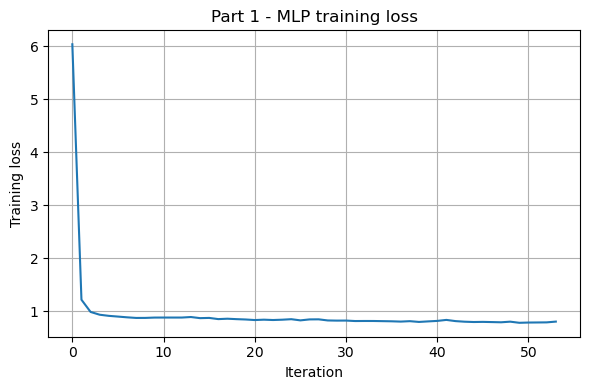

In [10]:
plt.figure(figsize=(6, 4))
plt.plot(mlp_model_clean.named_steps["reg"].loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("Part 1 - MLP training loss")
plt.grid(True)

plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_mlp_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

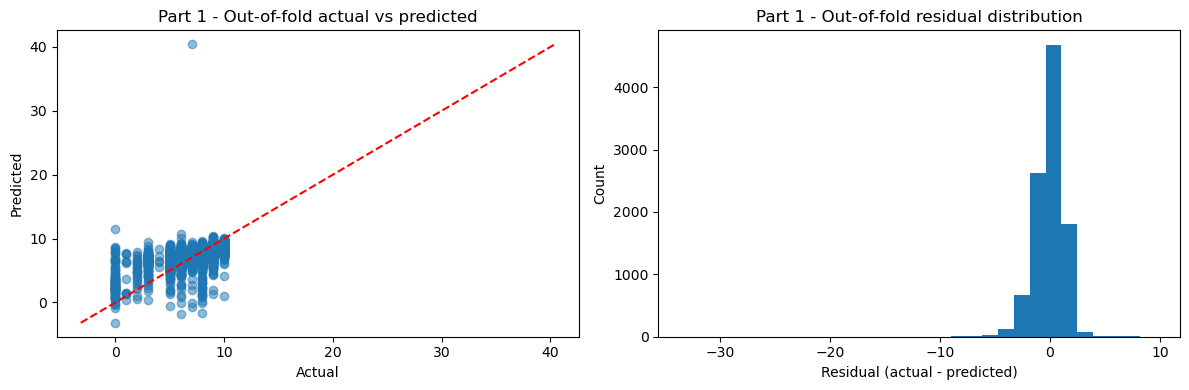

In [11]:
#OOF=Out-of-fold diagnostics
residuals = y - y_pred_oof

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y, y_pred_oof, alpha=0.5)
lims = [min(y.min(), y_pred_oof.min()), max(y.max(), y_pred_oof.max())]
ax[0].plot(lims, lims, "r--")
ax[0].set_title("Part 1 - Out-of-fold actual vs predicted")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")

ax[1].hist(residuals, bins=30)
ax[1].set_title("Part 1 - Out-of-fold residual distribution")
ax[1].set_xlabel("Residual (actual - predicted)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_oof_diagnostics.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [12]:
pred_df = X.copy()
pred_df["y_true"] = y.values
pred_df["y_pred"] = y_pred_oof
pred_df["abs_err"] = np.abs(pred_df["y_true"] - pred_df["y_pred"])

print("Top errors by course:")
display(pred_df.groupby("course")["abs_err"].mean().sort_values(ascending=False).head(10))

print("Top errors by text_type:")
display(pred_df.groupby("text_type")["abs_err"].mean().sort_values(ascending=False).head(10))

Top errors by course:


course
5447    1.034559
3301    0.985407
Name: abs_err, dtype: float64

Top errors by text_type:


text_type
bericht         1.046369
beschreibung    1.025552
erzaehlung      1.023348
eroerterung     0.945479
Name: abs_err, dtype: float64

Ridge - 5-fold CV
MAE : 1.0976 +/- 0.0441
RMSE: 1.8448 +/- 0.8446
R2  : -0.6652 +/- 1.6705

Random Forest - 5-fold CV
MAE : 0.9685 +/- 0.0164
RMSE: 1.2977 +/- 0.0299
R2  : 0.3122 +/- 0.0319


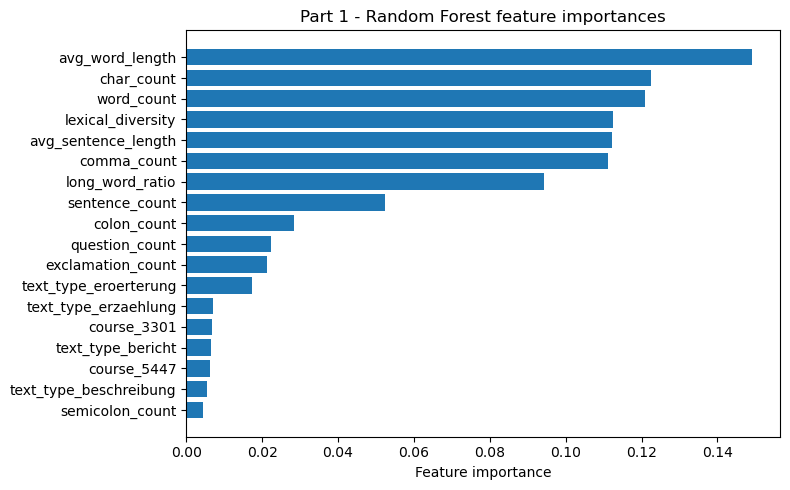

In [13]:
#Ridge regression
ridge_p1 = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

cv_scores_ridge_p1 = cross_validate(
    ridge_p1, X, y, cv=cv_part1,
    scoring={"mae": "neg_mean_absolute_error",
             "rmse": "neg_root_mean_squared_error",
             "r2": "r2"},
    n_jobs=-1
)

print("Ridge - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_ridge_p1["test_mae"].mean(), cv_scores_ridge_p1["test_mae"].std()))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_ridge_p1["test_rmse"].mean(), cv_scores_ridge_p1["test_rmse"].std()))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_ridge_p1["test_r2"].mean(), cv_scores_ridge_p1["test_r2"].std()))

# RF= Random Forest 
rf_p1 = Pipeline([
    ("prep", preprocessor),
    ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
])

cv_scores_rf_p1 = cross_validate(
    rf_p1, X, y, cv=cv_part1,
    scoring={"mae": "neg_mean_absolute_error",
             "rmse": "neg_root_mean_squared_error",
             "r2": "r2"},
    n_jobs=-1
)

print("\nRandom Forest - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_rf_p1["test_mae"].mean(), cv_scores_rf_p1["test_mae"].std()))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_rf_p1["test_rmse"].mean(), cv_scores_rf_p1["test_rmse"].std()))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_rf_p1["test_r2"].mean(), cv_scores_rf_p1["test_r2"].std()))

#Feature importance from RF (fit on full data)
rf_p1.fit(X, y)
importances = rf_p1.named_steps["reg"].feature_importances_

# recover feature names after preprocessing
ohe_features = rf_p1.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
all_feature_names = list(ohe_features) + num_cols

fi_df = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(fi_df["feature"][::-1], fi_df["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Part 1 - Random Forest feature importances")
plt.tight_layout()
plt.savefig(f"{fig_dir}/part1_rf_feature_importances.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Interim result for Part 1

The MLP achieves MAE=1.02 and R²=0.22, while the Random Forest reaches MAE=0.97 and R²=0.31, both well above the dummy baseline (R²≈0). This confirms that surface linguistic features carry genuine predictive signal. RF outperforms MLP here, likely because the small feature space (12 features) does not benefit from the added complexity of a neural network. The dominant predictors are avg_word_length, word_count, and lexical_diversity,  suggesting that coherence is largely driven by how richly and extensively a student writes.

## Part 2 — Essay analysis with richer semantic features
After building a first baseline with simple surface-level linguistic features, we extend the essay analysis by incorporating richer semantic representations of the text.

We ask the following question:

**Do richer semantic text features improve the prediction of essay performance compared with simple linguistic surface features alone?**

In this second step, we keep the same essay-based setting and the same prediction framework, but we move from basic handcrafted features toward more informative text representations.

The goal is to evaluate whether semantic information contained in students' essays provides additional predictive value for essay assessment outcomes.

In [14]:
german_stopwords = [
    "aber", "als", "am", "an", "auch", "auf", "aus", "bei", "bin", "bis",
    "bist", "da", "dadurch", "daher", "darum", "das", "daß", "dass", "dein",
    "deine", "dem", "den", "der", "des", "dessen", "deshalb", "die", "dies",
    "dieser", "dieses", "doch", "dort", "du", "durch", "ein", "eine", "einem",
    "einen", "einer", "eines", "er", "es", "euer", "eure", "für", "hatte",
    "hatten", "hattest", "hattet", "hier", "hinter", "ich", "ihr", "ihre",
    "im", "in", "ist", "ja", "jede", "jedem", "jeden", "jeder", "jedes",
    "jener", "jenes", "jetzt", "kann", "kannst", "können", "könnt", "machen",
    "mein", "meine", "mit", "muß", "mußt", "musst", "müssen", "müsst",
    "nach", "nachdem", "nein", "nicht", "nun", "oder", "seid", "sein",
    "seine", "sich", "sie", "sind", "soll", "sollen", "sollst", "sollt",
    "sonst", "soweit", "sowie", "und", "unser", "unsere", "unter", "vom",
    "von", "vor", "wann", "warum", "was", "weiter", "weitere", "wenn",
    "wer", "werde", "werden", "werdet", "weshalb", "wie", "wieder", "wieso",
    "wir", "wird", "wirst", "wo", "woher", "wohin", "zu", "zum", "zur",
    "über"
]

## Feature Engineering — Part 2 (TF-IDF Semantic Representation)

In Part 2 we move beyond surface structure and represent each essay as a high-dimensional vector of weighted word frequencies, using TF-IDF (Term Frequency–Inverse Document Frequency). This representation captures 
which words are characteristically used in each essay relative to the full corpus, allowing the model to pick up on lexical and topical patterns invisible to surface features.

**Preprocessing pipeline applied to raw German essay text:**
1. Lowercasing and removal of punctuation and digits
2. Tokenization using a custom regex pattern that retains German characters 
   (ä, ö, ü, ß) and filters out tokens shorter than 2 characters
3. Stopword removal using a custom German stopword list (covering function words, 
   pronouns, auxiliary verbs)

**TF-IDF configuration:**
- `ngram_range=(1,1)` : unigrams only, keeping the vocabulary interpretable
- `min_df=3` : terms must appear in at least 3 essays to be included, filtering noise
- `max_df=0.90` : terms appearing in more than 90% of essays are excluded as 
  uninformative
- `max_features=5000` : vocabulary capped at the 5,000 most informative terms
- `sublinear_tf=True` : log-scaling of term frequencies to reduce the dominance 
  of very frequent terms

The same categorical covariates (`course`, `text_type`) from Part 1 are appended to the TF-IDF matrix as one-hot encoded columns. The resulting feature matrix combines lexical content with contextual metadata, giving the Ridge regression model both semantic and structural signals to work with.

The key hypothesis here is that discourse connectors, argumentative vocabulary, and topic-relevant terminology should receive high TF-IDF weights in coherent essays, and the Ridge coefficients should reflect this if the hypothesis holds.

In [15]:
#data selection for Part 2
df_semantic = essay_results[["course", "text_type", "text", "structure__coherence"]].copy()
df_semantic = df_semantic.dropna(subset=["course", "text_type", "text", "structure__coherence"]).copy()

df_semantic["text_clean"] = df_semantic["text"].apply(helpers.clean_german_essay_text)

X = df_semantic[["course", "text_type", "text_clean"]].copy()
y = df_semantic["structure__coherence"].copy()

cv_part2 = KFold(n_splits=5, shuffle=True, random_state=42)

In [16]:
#Preprocessing
text_col = "text_clean"
cat_cols = ["course", "text_type"]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                lowercase=True,
                stop_words=german_stopwords,
                ngram_range=(1, 1),
                min_df=3,
                max_df=0.90,
                max_features=5000,
                sublinear_tf=True,
                token_pattern=r"(?u)\b[a-zA-ZäöüÄÖÜß]{2,}\b"
            ),
            text_col
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            cat_cols
        )
    ],
    remainder="drop"
)


In [17]:
#model
ridge_model = Pipeline([
    ("prep", preprocessor),
    ("reg", Ridge(alpha=1.0))
])

In [18]:
#Model fitting on full data
ridge_model.fit(X, y)

,steps,"[('prep', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('text', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


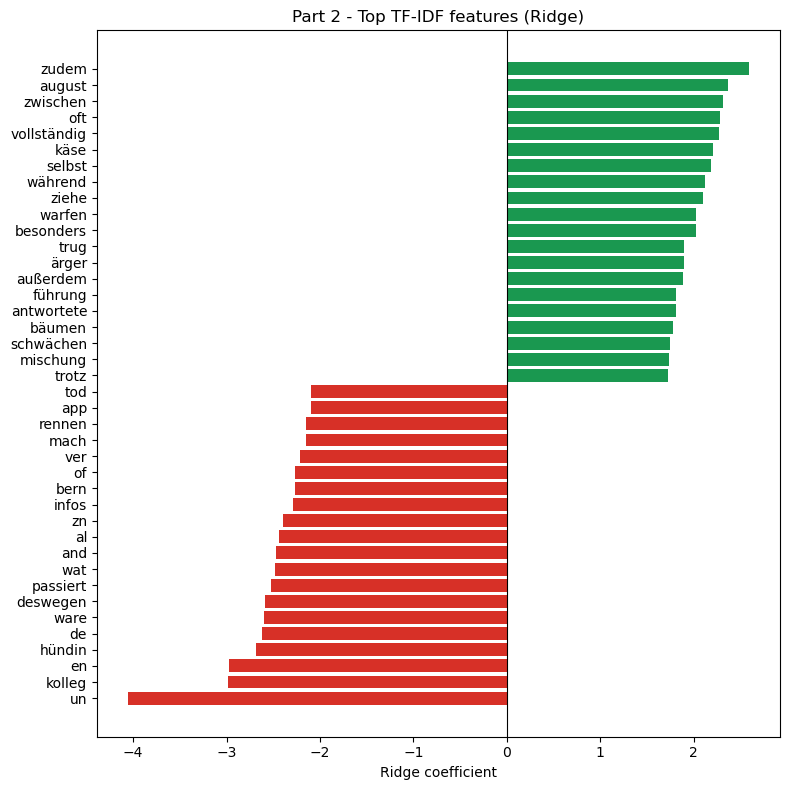

In [19]:
tfidf = ridge_model.named_steps["prep"].named_transformers_["text"]
ridge_coefs = ridge_model.named_steps["reg"].coef_

tfidf_feature_names = tfidf.get_feature_names_out()
ohe_features = ridge_model.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat_cols)
all_names = list(tfidf_feature_names) + list(ohe_features)

coef_df = pd.DataFrame({
    "feature": all_names,
    "coef": ridge_coefs
}).sort_values("coef", ascending=False)

#top 20 positive and negative TF-IDF 
coef_tfidf = coef_df[coef_df["feature"].isin(tfidf_feature_names)]
top_pos = coef_tfidf.head(20)
top_neg = coef_tfidf.tail(20)
top = pd.concat([top_pos, top_neg]).sort_values("coef")

plt.figure(figsize=(8, 8))
colors = ["#d73027" if c < 0 else "#1a9850" for c in top["coef"]]
plt.barh(top["feature"], top["coef"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Ridge coefficient")
plt.title("Part 2 - Top TF-IDF features (Ridge)")
plt.tight_layout()
plt.savefig(f"{fig_dir}/part2_top_tfidf_features_ridge.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

Words in red are associated with lower coherence score. Words in green are associated with higher coherence score.

In [20]:
#model evaluation with cross-validation
cv_scores_p2 = cross_validate(
    ridge_model,
    X,
    y,
    cv=cv_part2,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=-1,
    return_train_score=False
)

print("Part 2 - 5-fold CV")
print("MAE : {:.4f} +/- {:.4f}".format(
    -cv_scores_p2["test_mae"].mean(), cv_scores_p2["test_mae"].std()
))
print("RMSE: {:.4f} +/- {:.4f}".format(
    -cv_scores_p2["test_rmse"].mean(), cv_scores_p2["test_rmse"].std()
))
print("R2  : {:.4f} +/- {:.4f}".format(
    cv_scores_p2["test_r2"].mean(), cv_scores_p2["test_r2"].std()
))

Part 2 - 5-fold CV
MAE : 0.9211 +/- 0.0164
RMSE: 1.2712 +/- 0.0267
R2  : 0.3406 +/- 0.0062


## Interim result for Part 2

The TF-IDF Ridge model achieves MAE=0.92 and R²=0.34 (std=0.006) across 5-fold CV. This marginally outperforms the best surface model (RF, R²=0.31) while being significantly more stable across folds. The low variance confirms that lexical content provides a consistent and reproducible predictive signal for essay coherence. The Ridge coefficient plot further reveals that this signal is semantically meaningful: discourse connectors (zudem, außerdem, während) are strongly associated with higher coherence, while noise tokens and informal language drive scores down.

## Part 3 — Comparison of surface and word-based text representations

In this part, we compare the two essay-based modeling approaches developed previously:

- Part 1: simple engineered surface-level linguistic features
- Part 2: word-based text representations using TF-IDF

The goal is to assess which type of representation is more informative for predicting the essay score `structure__coherence`, and to better understand what this reveals about the nature of the target.

This comparison helps determine whether essay coherence is better captured by explicit structural features or by lexical content extracted directly from the text.

,MAE,R2
Model,,
Dummy,1.2065 +/- 0.0197,-0.0001 +/- 0.0001
MLP (surface),1.0159 +/- 0.0266,0.2201 +/- 0.1027
RF (surface),0.9685 +/- 0.0164,0.3122 +/- 0.0319
Ridge (TF-IDF),0.9211 +/- 0.0164,0.3406 +/- 0.0062


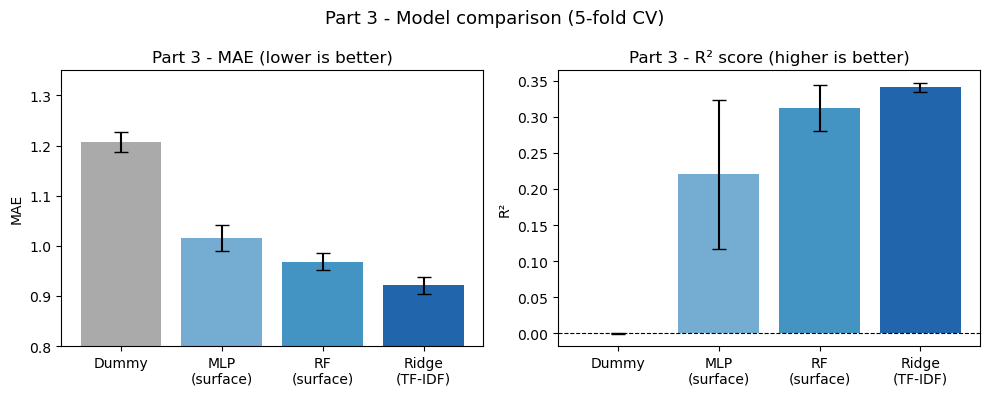

In [22]:
models = ["Dummy", "MLP\n(surface)", "RF\n(surface)", "Ridge\n(TF-IDF)"]

mae = [-cv_scores_dummy["test_mae"].mean(),
       -cv_scores_part1["test_mae"].mean(),
       -cv_scores_rf_p1["test_mae"].mean(),
       -cv_scores_p2["test_mae"].mean()]

mae_std = [cv_scores_dummy["test_mae"].std(),
           cv_scores_part1["test_mae"].std(),
           cv_scores_rf_p1["test_mae"].std(),
           cv_scores_p2["test_mae"].std()]

r2 = [cv_scores_dummy["test_r2"].mean(),
      cv_scores_part1["test_r2"].mean(),
      cv_scores_rf_p1["test_r2"].mean(),
      cv_scores_p2["test_r2"].mean()]

r2_std = [cv_scores_dummy["test_r2"].std(),
          cv_scores_part1["test_r2"].std(),
          cv_scores_rf_p1["test_r2"].std(),
          cv_scores_p2["test_r2"].std()]

df_results = pd.DataFrame({
    "Model": models,
    "MAE": [f"{m:.4f} +/- {s:.4f}" for m, s in zip(mae, mae_std)],
    "R2": [f"{r:.4f} +/- {s:.4f}" for r, s in zip(r2, r2_std)],
}).set_index("Model")
display(df_results.style
    .set_caption("Model comparison (5-fold CV)")
)

x = np.arange(len(models))
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

colors = ["#aaaaaa", "#74add1", "#4393c3", "#2166ac"]

ax[0].bar(x, mae, yerr=mae_std, capsize=5, color=colors)
ax[0].set_xticks(x)
ax[0].set_xticklabels(models)
ax[0].set_ylabel("MAE")
ax[0].set_title("Part 3 - MAE (lower is better)")
ax[0].set_ylim(0.8, 1.35)

ax[1].bar(x, r2, yerr=r2_std, capsize=5, color=colors)
ax[1].set_xticks(x)
ax[1].set_xticklabels(models)
ax[1].set_ylabel("R²")
ax[1].set_title("Part 3 - R² score (higher is better)")
ax[1].axhline(0, color="black", linewidth=0.8, linestyle="--")

plt.suptitle("Part 3 - Model comparison (5-fold CV)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{fig_dir}/part3_model_comparison_cv.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

## Part 3 — Conclusion

The progressive comparison across four models reveals a consistent improvement from dummy to MLP to RF to Ridge TF-IDF. However, the gains diminish at each step: moving from MLP to RF (+0.09 R²) brings more improvement than moving from RF to Ridge TF-IDF (+0.03 R²). This suggests that much of the predictive signal in essay coherence is already captured by surface structural properties, and that richer lexical representations offer only marginal additional gains.

Neither representation achieves R² above 0.35, indicating that a substantial portion of variance in coherence scores remains unexplained by text features alone, pointing to the limits of bag-of-words approaches and motivating future work with contextual embeddings (e.g. sentence-BERT).

## Part 4 — Toward a Human-Labeled Target: Teacher Grades

Throughout Parts 1–3 we predicted `structure__coherence`, an AI-generated score 
derived from the same essay text used as input. This raises a circularity concern: 
the model may be learning to reverse-engineer the automated scorer rather than 
capturing genuine writing quality.

A more robust validation would use an independent human label. `essay_feedback.csv` 
provides `teacher_grade`, but it is unusable as a target for two reasons:

1. **Sample size:** only 157 of 10,195 essays (~1.5%) carry a teacher grade — far 
   too few for reliable 5-fold cross-validation.

2. **Self-reported label:** the documentation notes this grade is recorded 
   "according to the student", i.e. self-reported rather than taken directly from 
   the teacher, introducing recall bias.

We quantify the coverage below.

In [28]:
essay_feedback = pd.read_csv('{}/essay_feedback.csv'.format(data_dir))

print(essay_feedback.shape)
print(essay_feedback.head())
print(essay_feedback["teacher_grade"].isna().sum(), "missing teacher grades")
print(essay_feedback["teacher_grade"].notna().sum(), "available teacher grades")

(1009, 5)
   Unnamed: 0                             result_id  feedback_rating  \
0           0  c4ee0aa0-4137-46f7-aea9-548d0047712f              0.0   
1           1  5bb94ccf-1b01-405d-b396-a851011abf04              2.0   
2           2  bd5f07e6-6a97-4f3a-85ce-03b299db8dc2              5.0   
3           3  e46214af-cac6-48b9-b0da-2d4f14c000cb              0.0   
4           4  72d371ff-d0b1-4063-a94a-852908874410              4.0   

                                feedback_text  teacher_grade  
0                                         NaN            NaN  
1  Naja ich hätte eine bessere Note erwartet.            6.0  
2               Ich habe kein Fehler gemacht.            7.0  
3                                         NaN            NaN  
4                Streng aber gut bewertet☺️\n            NaN  
852 missing teacher grades
157 available teacher grades


In [29]:
total_essays = essay_results.shape[0]
total_feedback = essay_feedback.shape[0]
graded = essay_feedback["teacher_grade"].notna().sum()
feedback_no_grade = total_feedback - graded
no_feedback = total_essays - total_feedback

print(f"Total essays submitted:           {total_essays}")
print(f"No teacher feedback at all:       {no_feedback} ({100*no_feedback/total_essays:.1f}%)")
print(f"Teacher feedback, but no grade:   {feedback_no_grade} ({100*feedback_no_grade/total_essays:.1f}%)")
print(f"Teacher grade available:          {graded} ({100*graded/total_essays:.1f}%)")

Total essays submitted:           10195
No teacher feedback at all:       9186 (90.1%)
Teacher feedback, but no grade:   852 (8.4%)
Teacher grade available:          157 (1.5%)


## Part 4 — Conclusion

With only ~1.5% of essays carrying a human grade, validating against independent ground truth is statistically infeasible, so we retain `structure__coherence` as our target. Our models therefore demonstrate that surface and lexical features partially capture *what the automated scorer measures*, whether this fully reflects human-judged writing quality remains an open question, and independent validation is left for future work. The generalization analysis in Part 5 directly addresses this concern.

## Part 5 - Generalization across essay score dimensions

In [25]:
targets = {
    "structure__coherence": df_clean,  # already computed
    "language__word_choice": None,
    "content__on_topic": None,
    "structure__outline": None,
}

results = []

for target in ["structure__coherence", "language__word_choice", "content__on_topic", "structure__outline"]:
    # build df for this target
    df_t = essay_results[["course", "text_type", "text", target]].dropna().copy()
    df_t["word_count"] = df_t["text"].apply(helpers.word_count)
    df_t["char_count"] = df_t["text"].apply(helpers.char_count)
    df_t["sentence_count"] = df_t["text"].apply(helpers.sentence_count)
    df_t["avg_sentence_length"] = df_t["text"].apply(helpers.avg_sentence_length)
    df_t["avg_word_length"] = df_t["text"].apply(helpers.avg_word_length)
    df_t["lexical_diversity"] = df_t["text"].apply(helpers.lexical_diversity)
    df_t["comma_count"] = df_t["text"].apply(helpers.comma_count)
    df_t["semicolon_count"] = df_t["text"].apply(helpers.semicolon_count)
    df_t["colon_count"] = df_t["text"].apply(helpers.colon_count)
    df_t["exclamation_count"] = df_t["text"].apply(helpers.exclamation_count)
    df_t["question_count"] = df_t["text"].apply(helpers.question_count)
    df_t["long_word_ratio"] = df_t["text"].apply(helpers.long_word_ratio)

    X_t = df_t[feature_cols].copy()
    y_t = df_t[target].copy()

    # RF surface
    scores_rf = cross_validate(rf_p1, X_t, y_t, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                               scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}, n_jobs=-1)
    
    # Ridge TF-IDF
    df_t["text_clean"] = df_t["text"].apply(helpers.clean_german_essay_text)
    X_tfidf = df_t[["course", "text_type", "text_clean"]].copy()
    scores_ridge = cross_validate(ridge_model, X_tfidf, y_t, cv=KFold(n_splits=5, shuffle=True, random_state=42),
                                  scoring={"r2": "r2", "mae": "neg_mean_absolute_error"}, n_jobs=-1)

    results.append({
        "target": target,
        "RF R²": f"{scores_rf['test_r2'].mean():.3f} ± {scores_rf['test_r2'].std():.3f}",
        "Ridge R²": f"{scores_ridge['test_r2'].mean():.3f} ± {scores_ridge['test_r2'].std():.3f}",
        "RF MAE": f"{-scores_rf['test_mae'].mean():.3f}",
        "Ridge MAE": f"{-scores_ridge['test_mae'].mean():.3f}",
    })

df_generalization = pd.DataFrame(results).set_index("target")
display(df_generalization)

,RF R²,Ridge R²,RF MAE,Ridge MAE
target,,,,
structure__coherence,0.312 ± 0.032,0.341 ± 0.006,0.968,0.921
language__word_choice,0.416 ± 0.011,0.485 ± 0.013,0.457,0.427
content__on_topic,0.275 ± 0.025,0.173 ± 0.016,0.970,1.102
structure__outline,0.322 ± 0.024,0.342 ± 0.014,0.550,0.527


To assess whether our models capture genuine writing signals rather than 
overfitting to one specific AI scorer dimension, we apply the same RF 
(surface features) and Ridge (TF-IDF) pipelines to three additional 
score dimensions from `essay_results.csv`.

| Target | RF R² | Ridge R² |
|---|---|---|
| structure__coherence | 0.312 | 0.341 |
| language__word_choice | 0.416 | 0.485 |
| content__on_topic | 0.275 | 0.173 |
| structure__outline | 0.322 | 0.342 |

Three findings stand out:

**1. `language__word_choice` is the most predictable dimension (RF=0.42, Ridge=0.49).**
This makes intuitive sense: vocabulary richness features like `avg_word_length`, 
`lexical_diversity`, and `long_word_ratio` directly measure word choice quality. 
The model is not just reverse-engineering the AI scorer — it is capturing a 
signal that maps cleanly onto a linguistically meaningful construct.

**2. `content__on_topic` breaks the pattern.**
Ridge TF-IDF drops to R²=0.17, far below RF (0.28). This is the one dimension 
where surface features outperform lexical content — likely because topic relevance 
depends on *what* is written, not *how*, and bag-of-words representations 
conflate topic with quality. RF's structural features are more robust here.

**3. Surface and lexical features generalize consistently across dimensions.**
RF achieves R² between 0.27 and 0.42 across all targets, confirming that the 
predictive signal is not specific to coherence. Our features capture broad 
writing quality signals that the AI scorer measures across multiple dimensions.
This is a strong addition — it elevates SQ1 from "we predict one AI score" to "we show our features generalize across writing quality dimensions." Ready to close SQ1 for real now?Sonnet 4.6